# Physical data and regional fuel balances

**Scope.** This notebook builds the weekly physical-data table used by the forecast model. It combines EIA inventories, refinery activity, output, trade, and OpenSky flight activity by U.S. region.

**Model premise.** Regional spreads should reflect local fuel balance. Inventories, refinery activity, incoming fuel, outgoing fuel, and consumption measure that balance and can be tested against the spreads.

**Data sources.** The **EIA** is the U.S. Energy Information Administration, which publishes weekly oil statistics by region. Its five regional districts are called **PADDs**. PADD 1 is the East Coast, PADD 3 is the Gulf Coast, and PADD 5 is the West Coast. **OpenSky** is a public network of receivers that records aircraft positions; those records are converted into miles flown over each region.

**Publication timing.** Each model input is dated by the weekend when it became public. The EIA releases Wednesday data for the week ending the prior Friday, so the model shifts those values to the first weekend when a trader could have read them.

**Data vintage.** The EIA series are current revised values. The historical tests therefore use cleaner data than was available in real time.

**Interpretation.** Same-week correlation measures association between physical conditions and spreads. Predictive evidence is tested separately against the following week's spread change.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')   # KPSS p-value table bounds

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_rows', 200)
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True

In [2]:
# Input files and settings
PRICES_FILE = '../data/prices_clean.csv'
DOE_FILE = '../bloomberg_data/doe_data.csv'
BALANCE_FILES = {1: '../supporting_data/EIA_PADD1_BALANCES', 2: '../supporting_data/PADD2_Balances.csv', 3: '../supporting_data/PADD3_Balances.csv',
                 4: '../supporting_data/PADD4_Balances.csv', 5: '../supporting_data/PADD5_Balances.csv'}
TRADE_FILE = '../eia_imp_exp/weekly_padd_trade_EPJK.csv'
MOVES_FILE = '../eia_imp_exp/monthly_movements_between_padds_EPJK.csv'
MILES_FILE = '../supporting_data/everything_6.xlsx'

START = '2015-01-09'            # output from 2015-01-02, plus one week for stock change
PRE_COVID_END = '2020-02-28'


## Settings

**Method.** Names every input file and fixes two dates: the data starts 9 January 2015,
and the pre-pandemic period ends 28 February 2020.

**Reason.** In March 2020 jet fuel demand fell by about 80 percent. Any average that
includes those weeks is a description of those weeks and not of the market. Fixing the cutoff
before running anything means the pandemic cannot drive a result that gets reported as
normal behaviour.

**Start date.** The regional balance data this notebook needs does not exist in a
consistent form before then.

**Interpretation.** Every test in this file runs on 9 January 2015 to 28 February 2020 unless a cell
says otherwise, and the pandemic weeks are examined where they are examined at all.

In [3]:
PRICES = pd.read_csv(PRICES_FILE, index_col=0, parse_dates=True)
PRICES.index.name = 'week_ending'
print(PRICES.shape, PRICES.index.min().date(), 'to', PRICES.index.max().date())
print('every row a Friday:', (PRICES.index.dayofweek == 4).all(), '| gaps between rows (days):', PRICES.index.to_series().diff().dropna().unique())

(492, 57) 2011-01-07 to 2020-06-05
every row a Friday: True | gaps between rows (days): <TimedeltaArray>
['7 days']
Length: 1, dtype: timedelta64[ns]


In [4]:
# Weekly EIA series
DOE = pd.read_csv(DOE_FILE, index_col=0)
DOE = DOE.loc[:, ~DOE.columns.str.startswith('Unnamed')]
DOE.index = pd.to_datetime(DOE.index, format='%m/%d/%Y')
DOE.index.name = 'week_ending'
DOE = DOE.dropna(how='all')
print(DOE.shape, DOE.index.min().date(), 'to', DOE.index.max().date())

(491, 220) 2011-01-07 to 2020-05-29


In [5]:
# Jet output by PADD from 2015
OUTPUT = pd.DataFrame(index=PRICES.index)
for p, f in BALANCE_FILES.items():
    b = pd.read_csv(f, index_col=0, parse_dates=True)
    OUTPUT[f'P{p}_JET_OUTPUT'] = b[f'PADD{p}_prod']
OUTPUT['US_JET_OUTPUT'] = OUTPUT[[f'P{p}_JET_OUTPUT' for p in range(1, 6)]].sum(axis=1, min_count=5)
d = OUTPUT.dropna()
print(d.shape, d.index.min().date(), 'to', d.index.max().date())


(284, 6) 2015-01-02 to 2020-06-05


In [6]:
# Imports and exports by PADD
TRADE = pd.read_csv(TRADE_FILE, index_col=0, parse_dates=True)
TRADE.index.name = 'week_ending'
TRADE[['imports_R10', 'imports_R30', 'imports_R50', 'imports_NUS', 'exports_rt_R10', 'exports_rt_R30', 'exports_rt_R50', 'us_exports_mbbld']].loc['2019-01-04':'2019-02-01']

,imports_R10,imports_R30,imports_R50,imports_NUS,exports_rt_R10,exports_rt_R30,exports_rt_R50,us_exports_mbbld
week_ending,,,,,,,,
2019-01-04,56.0,0.0,167.0,223,18.64,239.92,33.28,294
2019-01-11,10.0,0.0,59.0,69,13.63,175.45,24.34,215
2019-01-18,19.0,0.0,86.0,105,16.23,208.91,28.98,256
2019-01-25,47.0,0.0,37.0,84,6.85,88.13,12.22,108
2019-02-01,114.0,0.0,103.0,217,15.37,153.52,22.74,193


In [7]:
# Trade-series source check
for p in [1, 3, 5]:
    gap = (TRADE[f'imports_R{p}0'] - DOE[f'DOEIJET{p} Index']).dropna().abs().max()
    print(f'PADD {p} jet imports: largest gap between the two files = {gap}')
print('US jet exports: largest gap =', (TRADE['us_exports_mbbld'] - DOE['DOEBKJET Index']).dropna().abs().max())

PADD 1 jet imports: largest gap between the two files = 0.0
PADD 3 jet imports: largest gap between the two files = 0.0
PADD 5 jet imports: largest gap between the two files = 0.0
US jet exports: largest gap = 0.0


In [8]:
# OpenSky miles per day for PADD 1 and PADD 5
MILES = pd.read_excel(MILES_FILE, sheet_name='sheet').set_index('date')[['P1_MILES', 'P5_MILES']]
MILES.index.name = 'week_ending'
print(MILES.shape, MILES.index.min().date(), 'to', MILES.index.max().date())


(75, 2) 2019-01-04 to 2020-06-05


In [9]:
F = pd.DataFrame(index=PRICES.index)
# Jet stocks
F['P1_JET_STOCKS'] = DOE['DOESJET1 Index']
F['P3_JET_STOCKS'] = DOE['DOESJET3 Index']
F['P5_JET_STOCKS'] = DOE['DOESJET5 Index']
F['US_JET_STOCKS'] = DOE['DOESJETK Index']
# Distillate stocks
F['P1_DIST_STOCKS'] = DOE['DOESDIS1 Index']
F['US_DIST_STOCKS'] = DOE['DOESDIST Index']
# Refinery runs and utilization
F['P1_RUNS'] = DOE['DOEPGRP1 Index']
F['P3_RUNS'] = DOE['DOEPGRP3 Index']
F['P5_RUNS'] = DOE['DOEPGRP5 Index']
F['US_RUNS'] = DOE['DOEPGRIN Index']
F['P5_UTIL'] = DOE['DOEPPCP5 Index']
F['US_UTIL'] = DOE['DOEPPERC Index']
# Jet output
F = F.join(OUTPUT[['P1_JET_OUTPUT', 'P3_JET_OUTPUT', 'P5_JET_OUTPUT', 'US_JET_OUTPUT']])
# Jet imports and exports
F['P1_JET_IMPORTS'] = TRADE['imports_R10']
F['P3_JET_IMPORTS'] = TRADE['imports_R30']
F['P5_JET_IMPORTS'] = TRADE['imports_R50']
F['US_JET_IMPORTS'] = TRADE['imports_NUS']
F['P1_JET_EXPORTS'] = TRADE['exports_rt_R10']
F['P3_JET_EXPORTS'] = TRADE['exports_rt_R30']
F['P5_JET_EXPORTS'] = TRADE['exports_rt_R50']
F['US_JET_EXPORTS'] = TRADE['us_exports_mbbld']
# Weekly stock change
for s in ['P1', 'P3', 'P5', 'US']:
    F[f'{s}_JET_STOCK_CHG'] = F[f'{s}_JET_STOCKS'].diff()
print(F.shape)
F.loc['2019-01-04':'2019-01-25'].T

(492, 28)


week_ending       2019-01-04  2019-01-11  2019-01-18  2019-01-25
P1_JET_STOCKS        8421.00     7007.00     8757.00     8098.00
P3_JET_STOCKS       14031.00    15116.00    14099.00    15511.00
P5_JET_STOCKS       10066.00    10244.00    10005.00    10043.00
US_JET_STOCKS       40510.00    40552.00    41174.00    41842.00
P1_DIST_STOCKS      43116.00    46808.00    46054.00    46917.00
US_DIST_STOCKS     140042.00   143009.00   142392.00   141270.00
P1_RUNS              1076.00     1154.00     1084.00      886.00
P3_RUNS              9535.00     9197.00     8997.00     8829.00
P5_RUNS              2663.00     2607.00     2518.00     2536.00
US_RUNS             17883.00    17599.00    17285.00    16759.00
P5_UTIL                93.80       91.80       88.70       89.40
US_UTIL                96.10       94.60       92.90       90.10
P1_JET_OUTPUT          94.00      121.00      112.00       84.00
P3_JET_OUTPUT         887.00      900.00      903.00      942.00
P5_JET_OUTPUT         526

In [10]:
NORMAL_COLS = ['P1_JET_STOCKS', 'P3_JET_STOCKS', 'P5_JET_STOCKS', 'US_JET_STOCKS', 'P1_DIST_STOCKS', 'US_DIST_STOCKS',
               'P1_RUNS', 'P3_RUNS', 'P5_RUNS', 'US_RUNS', 'P5_UTIL', 'US_UTIL',
               'P1_JET_STOCK_CHG', 'P3_JET_STOCK_CHG', 'P5_JET_STOCK_CHG', 'US_JET_STOCK_CHG']
ISO = F.index.isocalendar()
YEAR = ISO['year'].values
WEEK = np.minimum(ISO['week'].values, 52)      # week 53 as 52

for col in NORMAL_COLS:
    tmp = pd.DataFrame({'value': F[col].values, 'year': YEAR, 'week': WEEK})
    wide = tmp.pivot_table(index='week', columns='year', values='value')     # week x year
    five = wide.T.rolling(5, min_periods=3).mean().shift(1).T                # mean of years Y-5 to Y-1
    F[col + '_5Y'] = [five.loc[w, y] for w, y in zip(WEEK, YEAR)]
    F[col + '_VS_5Y'] = F[col] - F[col + '_5Y']

for s in ['P1', 'P3', 'P5', 'US']:
    F[f'{s}_JET_STOCKS_VS_5Y_PCT'] = 100 * F[f'{s}_JET_STOCKS_VS_5Y'] / F[f'{s}_JET_STOCKS_5Y']
print('first week with a five-year normal:', F['P5_JET_STOCKS_5Y'].first_valid_index().date())

first week with a five-year normal: 2014-01-03


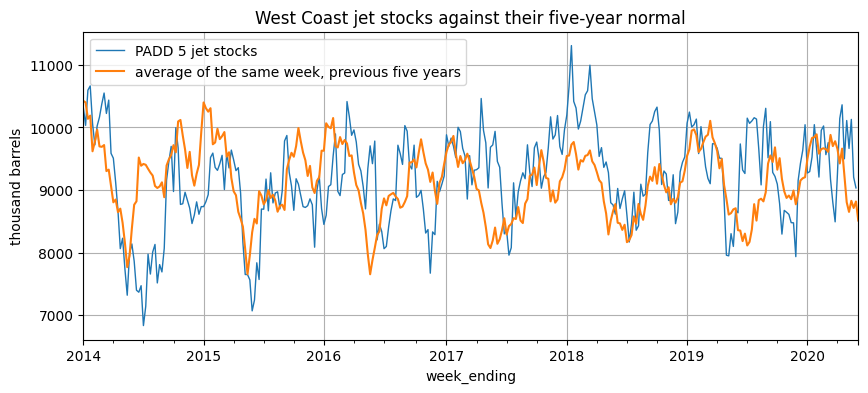

In [11]:
fig, ax = plt.subplots()
F.loc['2014':, 'P5_JET_STOCKS'].plot(ax=ax, label='PADD 5 jet stocks', lw=1)
F.loc['2014':, 'P5_JET_STOCKS_5Y'].plot(ax=ax, label='average of the same week, previous five years', lw=1.5)
ax.set_ylabel('thousand barrels')
ax.set_title('West Coast jet stocks against their five-year normal')
ax.legend()
plt.show()

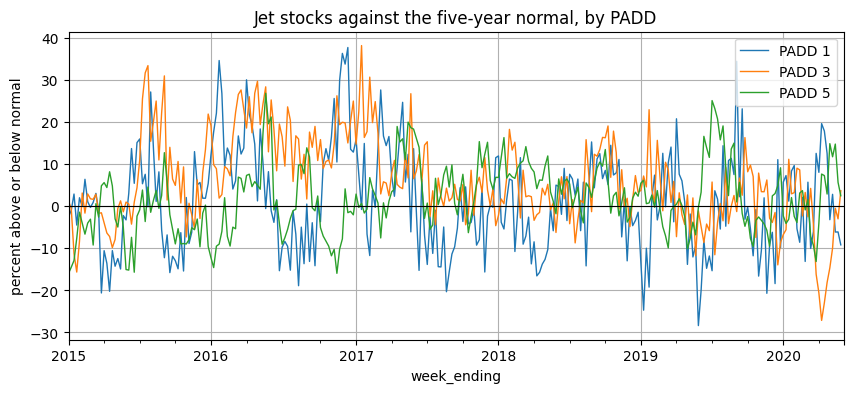

In [12]:
fig, ax = plt.subplots()
for s in ['P1', 'P3', 'P5']:
    F.loc['2015':, f'{s}_JET_STOCKS_VS_5Y_PCT'].plot(ax=ax, label=f'PADD {s[1]}', lw=1)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('percent above or below normal')
ax.set_title('Jet stocks against the five-year normal, by PADD')
ax.legend()
plt.show()

In [13]:
# Percent versus seasonal normal, 2015 to February 2020
F.loc[START:PRE_COVID_END, ['P1_JET_STOCKS_VS_5Y_PCT', 'P3_JET_STOCKS_VS_5Y_PCT', 'P5_JET_STOCKS_VS_5Y_PCT']].describe().round(1)

,P1_JET_STOCKS_VS_5Y_PCT,P3_JET_STOCKS_VS_5Y_PCT,P5_JET_STOCKS_VS_5Y_PCT
count,269.0,269.0,269.0
mean,1.0,6.9,1.8
std,12.1,9.9,8.0
min,-28.4,-15.7,-16.0
25%,-8.4,0.5,-3.7
50%,0.2,5.2,1.2
75%,8.5,13.4,6.5
max,37.7,38.1,26.8


## 4. Regional demand and days of supply

**Method.** Calculates how much jet fuel the West Coast burns each week, and
how many days the fuel in tanks would cover.

**Reason.** The EIA publishes no regional jet fuel demand
figure, so it has to be inferred from an accounting identity: everything produced, plus everything
that arrived, minus everything that left, minus whatever went into storage, must have been burned.
The tank change is divided by 7 because stocks are reported as a level on one day while the other
figures are daily rates.

Days of supply is then stocks divided by average daily demand. It is the more useful of the two
because it is self-normalising: 18 days of supply means the same thing whether the region is large or
small, whereas a raw tank level does not tell you if it is a lot without knowing the demand it
serves.

**Four-week average.** Weekly demand derived this way
inherits the survey error of every input, so it is noisy. Averaging four weeks smooths that without
adding much lag.

**Result.** The identity checks out: applying it to the whole United States reproduces the
EIA's own published national demand to within 2.43 thousand barrels a day, with an average gap of
0.66 over 74 weeks. On a base above 1,500 thousand barrels a day that is an error well under half a
percent. West Coast demand averages 513.7 thousand barrels a day and varies by about 80.5 around
that. Days of supply averages 18.1.

**Interpretation.** Matching the published national figure that means the regional numbers
are being built correctly, which is the only available way to check them, since the regional
equivalent is not published. The demand column used downstream is the four-week average. West Coast
demand swinging by 80 out of 514, around 16 percent, is a quantity that moves by 16 percent week to week, which is part
of why the region's spreads move as much as they do.

In [14]:
F['P5_JET_DEMAND'] = F['P5_JET_OUTPUT'] + F['P5_JET_IMPORTS'] - F['P5_JET_EXPORTS'] - F['P5_JET_STOCK_CHG'] / 7
F['US_JET_DEMAND'] = F['US_JET_OUTPUT'] + F['US_JET_IMPORTS'] - F['US_JET_EXPORTS'] - F['US_JET_STOCK_CHG'] / 7
F['P5_JET_DEMAND_4W'] = F['P5_JET_DEMAND'].rolling(4).mean()
F['US_JET_DEMAND_4W'] = F['US_JET_DEMAND'].rolling(4).mean()
F['P5_DAYS_SUPPLY'] = F['P5_JET_STOCKS'] / F['P5_JET_DEMAND_4W']
F['US_DAYS_SUPPLY'] = F['US_JET_STOCKS'] / F['US_JET_DEMAND_4W']
F['P5_IMPORTS_4W'] = F['P5_JET_IMPORTS'].rolling(4).mean()

# Output versus the prior 52-week mean
F['P5_OUTPUT_VS_52W'] = F['P5_JET_OUTPUT'] - F['P5_JET_OUTPUT'].rolling(52).mean().shift(1)
F['P3_OUTPUT_VS_52W'] = F['P3_JET_OUTPUT'] - F['P3_JET_OUTPUT'].rolling(52).mean().shift(1)

F.loc[START:PRE_COVID_END, ['P5_JET_DEMAND', 'P5_JET_DEMAND_4W', 'P5_DAYS_SUPPLY', 'US_JET_DEMAND', 'US_DAYS_SUPPLY']].describe().round(1)

,P5_JET_DEMAND,P5_JET_DEMAND_4W,P5_DAYS_SUPPLY,US_JET_DEMAND,US_DAYS_SUPPLY
count,269.0,267.0,267.0,269.0,267.0
mean,513.7,514.0,18.1,1684.3,24.6
std,80.5,43.8,2.1,164.8,2.0
min,295.1,397.5,13.6,1173.6,20.5
25%,452.1,480.4,16.6,1556.7,23.0
50%,510.9,516.2,18.0,1674.0,24.7
75%,569.7,547.4,19.6,1808.9,26.1
max,785.1,609.6,24.4,2107.9,30.7


In [15]:
# National demand identity check against EIA demand
EIA_US_DEMAND = pd.read_excel(MILES_FILE, sheet_name='sheet').set_index('date')['US_DEM']
GAP = (F['US_JET_DEMAND'] - EIA_US_DEMAND).dropna()
print('weeks compared:', len(GAP), '| largest gap:', round(GAP.abs().max(), 2), '| average gap:', round(GAP.abs().mean(), 2), 'thousand barrels a day')

weeks compared: 74 | largest gap: 2.43 | average gap: 0.66 thousand barrels a day


In [1]:
print('EIA demand and stock columns use current revised historical values.')


EIA demand and stock columns use current revised historical values.


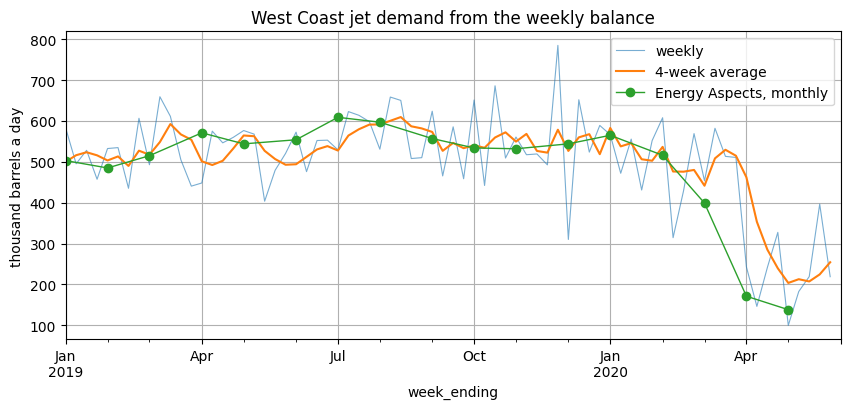

In [17]:
fig, ax = plt.subplots()
F.loc['2019':, 'P5_JET_DEMAND'].plot(ax=ax, label='weekly', lw=0.8, alpha=0.6)
F.loc['2019':, 'P5_JET_DEMAND_4W'].plot(ax=ax, label='4-week average', lw=1.5)
ax.set_ylabel('thousand barrels a day')
ax.set_title('West Coast jet demand from the weekly balance')
ax.legend()
plt.show()


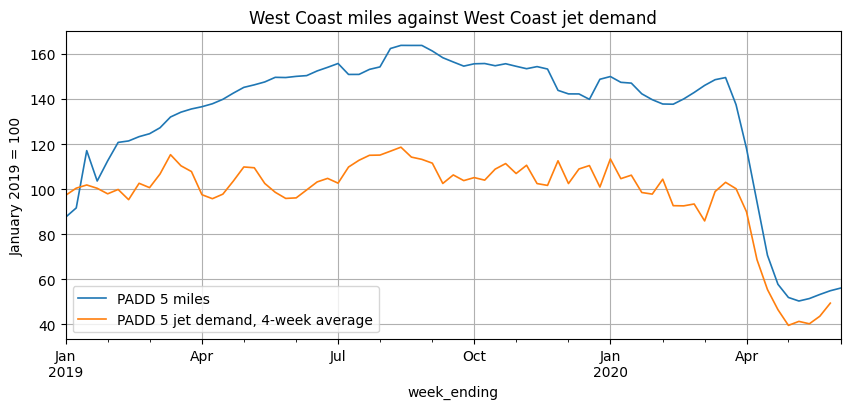

change from January 2019 to January 2020, percent:
P1_MILES            33.0
P5_MILES            45.3
P5_JET_DEMAND_4W     4.1
dtype: float64


In [18]:
M = MILES.join(F[['P5_JET_DEMAND_4W']])
BASE = M.loc['2019-01'].mean()
M_INDEX = 100 * M / BASE
fig, ax = plt.subplots()
M_INDEX['P5_MILES'].plot(ax=ax, label='PADD 5 miles', lw=1.2)
M_INDEX['P5_JET_DEMAND_4W'].plot(ax=ax, label='PADD 5 jet demand, 4-week average', lw=1.2)
ax.set_ylabel('January 2019 = 100')
ax.set_title('West Coast miles against West Coast jet demand')
ax.legend()
plt.show()
print('change from January 2019 to January 2020, percent:')
print((100 * (M.loc['2020-01'].mean() / M.loc['2019-01'].mean() - 1)).round(1))

In [19]:
MOVES = pd.read_csv(MOVES_FILE)
NET = MOVES[MOVES['series'].isin(['MKJNRP11', 'MKJNRP51'])].copy()     # net receipts, PADD 1 and 5
NET['month'] = pd.to_datetime(NET['period'])
NET['kbd'] = NET['value_mbbl'] / NET['month'].dt.days_in_month
NET = NET.pivot(index='month', columns='series', values='kbd').rename(columns={'MKJNRP11': 'P1_NET_RECEIPTS', 'MKJNRP51': 'P5_NET_RECEIPTS'})
print('2015-2019 average, thousand barrels a day:')
print(NET.loc['2015':'2019'].mean().round(1))
print('jet output over the same years:')
print(F.loc['2015':'2019', ['P1_JET_OUTPUT', 'P5_JET_OUTPUT']].mean().round(1))

2015-2019 average, thousand barrels a day:
series
P1_NET_RECEIPTS    463.8
P5_NET_RECEIPTS      8.6
dtype: float64
jet output over the same years:
P1_JET_OUTPUT     92.2
P5_JET_OUTPUT    451.1
dtype: float64


In [20]:
# Public availability begins on the first Friday of month m+3
NET['known_from'] = [m + pd.DateOffset(months=3) for m in NET.index]
NET['known_friday'] = [d + pd.Timedelta(days=(4 - d.weekday()) % 7) for d in NET['known_from']]
NET_KNOWN = pd.merge_asof(pd.DataFrame({'week_ending': F.index}),
                          NET.reset_index().sort_values('known_friday'),
                          left_on='week_ending', right_on='known_friday').set_index('week_ending')
NET_KNOWN = NET_KNOWN[['month', 'P1_NET_RECEIPTS', 'P5_NET_RECEIPTS']].rename(columns={'month': 'NET_RECEIPTS_MONTH'})
NET_KNOWN.loc['2019-06-07':'2019-07-12']

,NET_RECEIPTS_MONTH,P1_NET_RECEIPTS,P5_NET_RECEIPTS
week_ending,,,
2019-06-07,2019-03-01,514.935484,11.290323
2019-06-14,2019-03-01,514.935484,11.290323
2019-06-21,2019-03-01,514.935484,11.290323
2019-06-28,2019-03-01,514.935484,11.290323
2019-07-05,2019-04-01,504.200000,10.133333
2019-07-12,2019-04-01,504.200000,10.133333


## 7. Publication-time alignment

**Method.** Shifts every physical column forward by one week and marks the shifted
version, so that each row holds only what a trader could have read by that weekend.

**Reason.** The EIA publishes a week's inventory figure
several days after that week ends. Lining the figure up with the week it describes would let a
forecast use a number that did not exist yet. Models built that way look excellent and fail
immediately in use, and the failure is invisible unless the alignment is handled explicitly. This one
shift is the difference between a real test and a broken one.

**Result.** The table stores both versions of all 208 columns: the figure lined up with the week it describes, and the same figure lined up one week later, on the weekend it became readable.

**Interpretation.** Every test from here uses the readable version only. The raw version stays in the
table for reference, not for forecasting.

In [21]:
KNOWN = F.shift(1).add_suffix('_KNOWN')
PANEL = PRICES.join(F).join(KNOWN).join(NET_KNOWN.add_suffix('_KNOWN')).join(MILES)
print(PANEL.shape)

(492, 208)


In [22]:
ROW = pd.Timestamp('2019-06-14')
print('LA minus Gulf Coast jet, average of the week of 10 to 14 June:', round(PANEL.loc[ROW, 'LA_GC_1'], 2))
print('PADD 5 jet stocks known that weekend:', PANEL.loc[ROW, 'P5_JET_STOCKS_KNOWN'], '= EIA figure for the week ending', (ROW - pd.Timedelta(days=7)).date(), ':', F.loc[ROW - pd.Timedelta(days=7), 'P5_JET_STOCKS'])
print('PADD 5 jet stocks for the week ending 2019-06-14 itself (published the following Wednesday):', F.loc[ROW, 'P5_JET_STOCKS'])
print('PADD 5 miles for the week ending 2019-06-14:', round(PANEL.loc[ROW, 'P5_MILES']))
print('Net receipts known that weekend describe', PANEL.loc[ROW, 'NET_RECEIPTS_MONTH_KNOWN'].date(), ': PADD 1', round(PANEL.loc[ROW, 'P1_NET_RECEIPTS_KNOWN'], 1), '| PADD 5', round(PANEL.loc[ROW, 'P5_NET_RECEIPTS_KNOWN'], 1))

LA minus Gulf Coast jet, average of the week of 10 to 14 June: 6.16
PADD 5 jet stocks known that weekend: 8635.0 = EIA figure for the week ending 2019-06-07 : 8635.0
PADD 5 jet stocks for the week ending 2019-06-14 itself (published the following Wednesday): 9735.0
PADD 5 miles for the week ending 2019-06-14: 5696244
Net receipts known that weekend describe 2019-03-01 : PADD 1 514.9 | PADD 5 11.3


## 8. Physical-driver screening

**Method.** Runs the two return-to-normal tests from notebook 01 on each physical
driver, measures how much of each driver is seasonal, and checks whether any two drivers are one
number in two columns.

**Reason.** A fair value is a statement that a spread should sit at a
particular level given current conditions. That only works if the conditions themselves have a normal
level to be measured against. A driver that drifts permanently, like a raw inventory level trending
down for a decade, provides no anchor: the model cannot tell whether today's reading is high or low.

The second concern is two drivers carrying one piece of information. **Correlation** near 1 means two
columns move together to within a few percent. Fitting both splits one real effect across two coefficients that
then swing and can come out with opposite signs, which makes the model unstable and its
coefficients uninterpretable.

**Result.** Inventories, refinery runs and output measured *against their five-year seasonal
normal* do have a fixed level, which is what makes them usable. Two columns fail: distillate stocks
against normal, and four-week demand, both of which drift. Two pairs are near-duplicates: refinery
runs and refinery utilization correlate at 0.96, and national distillate stocks correlate with East
Coast distillate stocks at 0.96.

**Interpretation.** Measuring against a five-year seasonal normal is what converts a drifting
inventory level into a usable driver, because it subtracts both the long-run trend and the season and
leaves the part that says "tanks hold more than is normal for this time of year". That is the quantity a
trader reacts to. One of each near-duplicate pair is dropped, and the two drifting columns are
dropped as fair-value reference points.

In [23]:
DRIVERS = ['P5_JET_STOCKS_VS_5Y', 'P3_JET_STOCKS_VS_5Y', 'P1_JET_STOCKS_VS_5Y', 'US_JET_STOCKS_VS_5Y',
           'P5_DAYS_SUPPLY', 'US_DAYS_SUPPLY', 'P5_RUNS_VS_5Y', 'P3_RUNS_VS_5Y', 'P5_UTIL_VS_5Y', 'US_UTIL_VS_5Y',
           'P5_OUTPUT_VS_52W', 'P3_OUTPUT_VS_52W', 'P5_IMPORTS_4W', 'US_DIST_STOCKS_VS_5Y', 'P1_DIST_STOCKS_VS_5Y',
           'P5_JET_DEMAND_4W', 'US_JET_DEMAND_4W', 'P5_JET_STOCK_CHG_VS_5Y', 'US_JET_STOCK_CHG_VS_5Y']
W = F.loc[START:PRE_COVID_END]

STAT = pd.DataFrame(index=DRIVERS, columns=['first_week', 'weeks', 'adf_p', 'kpss_p', 'verdict'])
for name in DRIVERS:
    s = W[name].dropna()
    adf_p = adfuller(s, autolag='AIC')[1]
    kpss_p = kpss(s, regression='c', nlags='auto')[1]
    if adf_p < 0.05 and kpss_p >= 0.05:
        verdict = 'fixed level'
    elif adf_p >= 0.05 and kpss_p < 0.05:
        verdict = 'wanders'
    elif adf_p < 0.05 and kpss_p < 0.05:
        verdict = 'shifting level'
    else:
        verdict = 'unclear'
    STAT.loc[name] = [s.index.min().date(), len(s), round(adf_p, 3), round(kpss_p, 3), verdict]
STAT

                        first_week weeks  adf_p kpss_p         verdict
P5_JET_STOCKS_VS_5Y     2015-01-09   269    0.0  0.037  shifting level
P3_JET_STOCKS_VS_5Y     2015-01-09   269  0.004  0.018  shifting level
P1_JET_STOCKS_VS_5Y     2015-01-09   269    0.0    0.1     fixed level
US_JET_STOCKS_VS_5Y     2015-01-09   269  0.001    0.1     fixed level
P5_DAYS_SUPPLY          2015-01-23   267    0.0  0.036  shifting level
US_DAYS_SUPPLY          2015-01-23   267  0.002   0.01  shifting level
P5_RUNS_VS_5Y           2015-01-09   269    0.0    0.1     fixed level
P3_RUNS_VS_5Y           2015-01-09   269    0.0    0.1     fixed level
P5_UTIL_VS_5Y           2015-01-09   269    0.0    0.1     fixed level
US_UTIL_VS_5Y           2015-01-09   269    0.0   0.01  shifting level
P5_OUTPUT_VS_52W        2016-01-01   218    0.0    0.1     fixed level
P3_OUTPUT_VS_52W        2016-01-01   218  0.015    0.1     fixed level
P5_IMPORTS_4W           2015-01-09   269  0.021   0.01  shifting level
US_DIS

In [24]:
# Monthly seasonality R², raw and normalized
SEASON = pd.DataFrame(columns=['r_squared_month_raw', 'r_squared_month_vs_5y'])
for raw in ['P1_JET_STOCKS', 'P3_JET_STOCKS', 'P5_JET_STOCKS', 'US_JET_STOCKS', 'US_DIST_STOCKS', 'P5_RUNS']:
    out = []
    for col in [raw, raw + '_VS_5Y']:
        d = W[[col]].dropna().rename(columns={col: 'y'})
        d['month'] = d.index.month
        out.append(round(smf.ols('y ~ C(month)', data=d).fit().rsquared, 2))
    SEASON.loc[raw] = out
SEASON

,r_squared_month_raw,r_squared_month_vs_5y
P1_JET_STOCKS,0.15,0.05
P3_JET_STOCKS,0.12,0.03
P5_JET_STOCKS,0.31,0.15
US_JET_STOCKS,0.15,0.04
US_DIST_STOCKS,0.15,0.01
P5_RUNS,0.35,0.03


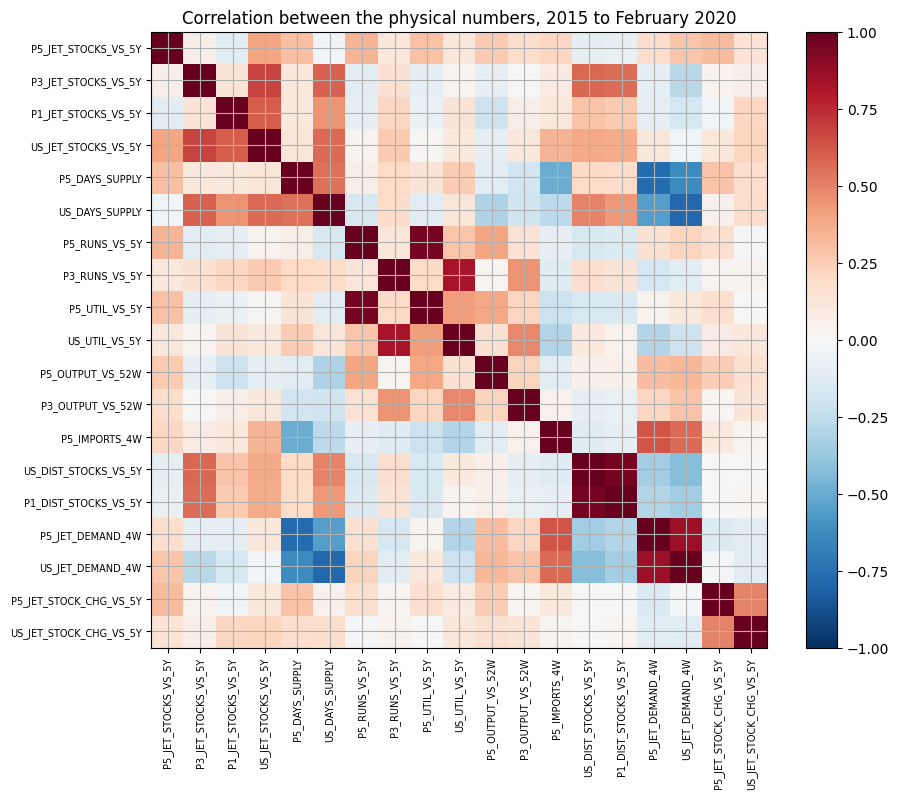

In [25]:
# Correlation and variance inflation factor
CORR = W[DRIVERS].corr()
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(CORR.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(DRIVERS)))
ax.set_xticklabels(DRIVERS, rotation=90, fontsize=7)
ax.set_yticks(range(len(DRIVERS)))
ax.set_yticklabels(DRIVERS, fontsize=7)
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title('Correlation between the physical numbers, 2015 to February 2020')
plt.show()

In [26]:
X = W[DRIVERS].dropna()
XC = sm.add_constant(X)
VIF = pd.Series([variance_inflation_factor(XC.values, i) for i in range(1, XC.shape[1])], index=DRIVERS, name='vif')
print('weeks used:', len(X))
VIF.sort_values(ascending=False).round(1)

weeks used: 218


P5_UTIL_VS_5Y             37.9
P5_RUNS_VS_5Y             34.0
US_DIST_STOCKS_VS_5Y      28.2
P1_DIST_STOCKS_VS_5Y      24.4
US_JET_STOCKS_VS_5Y       24.2
US_DAYS_SUPPLY            22.6
US_JET_DEMAND_4W          20.2
P3_JET_STOCKS_VS_5Y       10.4
P1_JET_STOCKS_VS_5Y        9.8
P5_JET_DEMAND_4W           9.5
P5_DAYS_SUPPLY             8.9
US_UTIL_VS_5Y              8.1
P3_RUNS_VS_5Y              6.9
P5_JET_STOCKS_VS_5Y        6.2
P5_OUTPUT_VS_52W           2.2
P5_IMPORTS_4W              2.2
P3_OUTPUT_VS_52W           2.0
P5_JET_STOCK_CHG_VS_5Y     1.9
US_JET_STOCK_CHG_VS_5Y     1.8
Name: vif, dtype: float64

In [27]:
# Highest-correlation pairs
PAIRS = []
for i in range(len(DRIVERS)):
    for j in range(i + 1, len(DRIVERS)):
        PAIRS.append([DRIVERS[i], DRIVERS[j], CORR.iloc[i, j]])
PAIRS = pd.DataFrame(PAIRS, columns=['driver_a', 'driver_b', 'correlation'])
PAIRS.reindex(PAIRS['correlation'].abs().sort_values(ascending=False).index).head(10).round(2)

,driver_a,driver_b,correlation
94,P5_RUNS_VS_5Y,P5_UTIL_VS_5Y,0.96
156,US_DIST_STOCKS_VS_5Y,P1_DIST_STOCKS_VS_5Y,0.96
165,P5_JET_DEMAND_4W,US_JET_DEMAND_4W,0.86
106,P3_RUNS_VS_5Y,US_UTIL_VS_5Y,0.82
90,US_DAYS_SUPPLY,US_JET_DEMAND_4W,-0.79
76,P5_DAYS_SUPPLY,P5_JET_DEMAND_4W,-0.77
19,P3_JET_STOCKS_VS_5Y,US_JET_STOCKS_VS_5Y,0.68
77,P5_DAYS_SUPPLY,US_JET_DEMAND_4W,-0.63
152,P5_IMPORTS_4W,P5_JET_DEMAND_4W,0.63
35,P1_JET_STOCKS_VS_5Y,US_JET_STOCKS_VS_5Y,0.61


## 9. Physical drivers and spread relationships

**Method.** Takes fourteen spread-and-driver pairs, writes down the sign each one should
have **before** looking, then measures three correlations for each: in the same week, on weekly
changes, and against the following week's spread change.

**Reason.** This is what makes the exercise a test instead of a description.
Physical reasoning says West Coast tanks filling up should narrow the Los Angeles premium, so the
correlation should be negative. Predicting the sign first means the data can disagree. Fitting first
and explaining afterwards can never fail, and so proves nothing.

**Result.** 13 of the 14 signs came out as predicted. The exception is Los Angeles minus Gulf
Coast against Gulf Coast inventories at −0.04, which is essentially zero. The largest correlations
are the heating-oil-versus-crude margin against distillate inventories at −0.68 and −0.69. Next-week
correlations, by contrast, run only from −0.08 to 0.13.

**Interpretation.** Thirteen of fourteen predicted signs support the stated physical relationships: regional scarcity measures are associated with wider regional spreads. The one miss makes sense on inspection, because the Gulf Coast is the other
leg of that particular spread, so its inventories pull the spread both ways at once and no clean sign
exists. It is kept for the Los Angeles fair value anyway, because the Gulf Coast leg has to be
represented somehow, and that choice is recorded here instead of hidden.

The gap between the two sets of numbers is the main result. Same-week correlations up to 0.69
describe the current state of the market well. Next-week correlations between −0.08 and 0.13 mean
little of next week's move is anticipated. So these drivers explain where the spread *is* far
better than where it is *going*, which is why the forecast that follows looks four weeks ahead rather
than one, and why no claim of causation is made anywhere in this file.

In [28]:
HYPOTHESES = [
    ('LA_GC_1', 'P5_JET_STOCKS_VS_5Y_KNOWN', '-', 'West Coast short of jet: LA premium rises'),
    ('LA_GC_1', 'P5_DAYS_SUPPLY_KNOWN', '-', 'same, measured against demand'),
    ('LA_GC_1', 'P5_RUNS_VS_5Y_KNOWN', '-', 'West Coast refinery outages cut supply'),
    ('LA_GC_1', 'P5_OUTPUT_VS_52W_KNOWN', '-', 'same, measured on jet output'),
    ('LA_GC_1', 'P3_JET_STOCKS_VS_5Y_KNOWN', '+', 'Gulf Coast long of jet: Gulf price falls'),
    ('LA_JET_M2M3', 'P5_JET_STOCKS_VS_5Y_KNOWN', '-', 'low stocks: nearer month trades above later month'),
    ('LA_JET_M2M3', 'P5_DAYS_SUPPLY_KNOWN', '-', 'same, measured against demand'),
    ('SING_GC_1', 'P3_JET_STOCKS_VS_5Y_KNOWN', '+', 'Gulf Coast long of jet: Gulf price falls against Asia'),
    ('SING_GC_1', 'P3_RUNS_VS_5Y_KNOWN', '+', 'Gulf Coast refineries run hard: more Gulf supply'),
    ('HO_BRENT', 'US_DIST_STOCKS_VS_5Y_KNOWN', '-', 'US short of distillate: crack rises'),
    ('HO_BRENT', 'P1_DIST_STOCKS_VS_5Y_KNOWN', '-', 'East Coast short of distillate: crack rises'),
    ('HO_BRENT', 'US_UTIL_VS_5Y_KNOWN', '-', 'refineries run hard: more supply'),
    ('NY_GC_1', 'P1_JET_STOCKS_VS_5Y_KNOWN', '-', 'East Coast short of jet: NY premium rises'),
    ('GC_JET_M1M2', 'P3_JET_STOCKS_VS_5Y_KNOWN', '-', 'low Gulf stocks: nearer month trades above later month'),
]
LOOK = PANEL.loc[START:PRE_COVID_END]
FIRST = pd.DataFrame(columns=['spread', 'physical_number', 'expected', 'reason', 'corr_level', 'sign_as_expected', 'corr_weekly_change', 'corr_next_week'])
for spread, driver, sign, reason in HYPOTHESES:
    lv = LOOK[spread].corr(LOOK[driver])
    ch = LOOK[spread].diff().corr(LOOK[driver].diff())
    nxt = (LOOK[spread].shift(-1) - LOOK[spread]).corr(LOOK[driver])
    as_expected = (lv < 0) if sign == '-' else (lv > 0)
    FIRST.loc[len(FIRST)] = [spread, driver, sign, reason, round(lv, 2), as_expected, round(ch, 2), round(nxt, 2)]
FIRST

         spread             physical_number expected                                             reason  corr_level  sign_as_expected  corr_weekly_change  corr_next_week
0       LA_GC_1   P5_JET_STOCKS_VS_5Y_KNOWN        -          West Coast short of jet: LA premium rises       -0.16              True                0.01            0.04
1       LA_GC_1        P5_DAYS_SUPPLY_KNOWN        -                      same, measured against demand       -0.14              True                0.01            0.13
2       LA_GC_1         P5_RUNS_VS_5Y_KNOWN        -             West Coast refinery outages cut supply       -0.14              True                0.05           -0.08
3       LA_GC_1      P5_OUTPUT_VS_52W_KNOWN        -                       same, measured on jet output       -0.31              True                0.01           -0.07
4       LA_GC_1   P3_JET_STOCKS_VS_5Y_KNOWN        +           Gulf Coast long of jet: Gulf price falls       -0.04             False                0

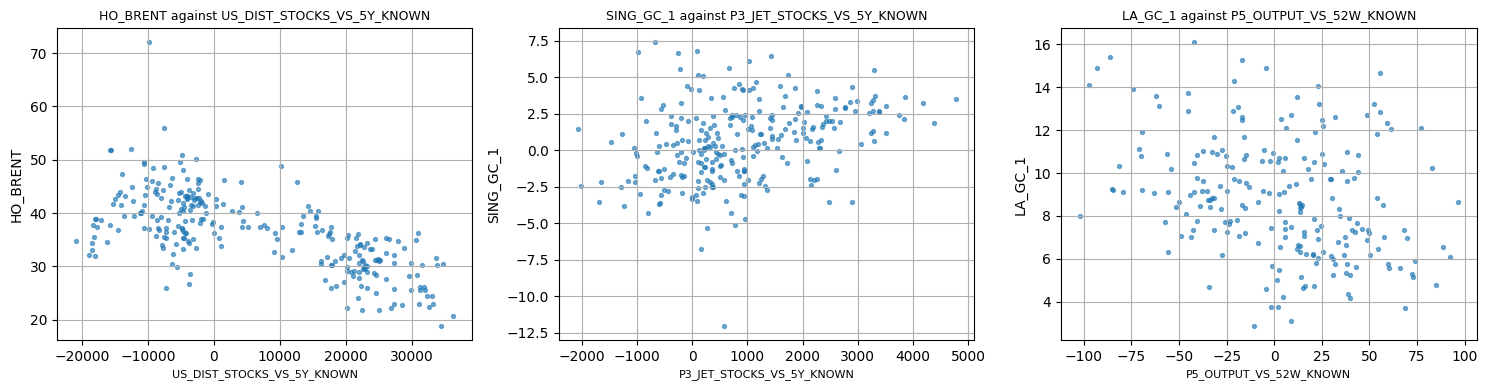

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (spread, driver) in zip(axes, [('HO_BRENT', 'US_DIST_STOCKS_VS_5Y_KNOWN'), ('SING_GC_1', 'P3_JET_STOCKS_VS_5Y_KNOWN'), ('LA_GC_1', 'P5_OUTPUT_VS_52W_KNOWN')]):
    ax.scatter(LOOK[driver], LOOK[spread], s=8, alpha=0.6)
    ax.set_xlabel(driver, fontsize=8)
    ax.set_ylabel(spread)
    ax.set_title(f'{spread} against {driver}', fontsize=9)
plt.tight_layout()
plt.show()

In [30]:
# Save outputs
PANEL.to_csv('../data/weekly_panel.csv')
print(PANEL.shape, PANEL.index.min().date(), 'to', PANEL.index.max().date())

(492, 208) 2011-01-07 to 2020-06-05


## Summary

| Check | Result | Consequence |
| --- | --- | --- |
| Regional demand reconstruction | Yes. The same arithmetic reproduces published national demand to within 2.43 thousand barrels a day, average gap 0.66 | Use the calculated regional demand, four-week average |
| Physical-driver stability | Yes, once measured against a five-year seasonal normal. Distillate stocks against normal and four-week demand still drift | Drop those two as fair-value anchors |
| Driver duplication | Yes. Refinery runs and utilization at 0.96; national and East Coast distillate stocks at 0.96 | Keep one of each pair |
| Physical sign checks | Yes. 13 of 14 predicted signs matched, the largest at −0.68 | Signs support the stated physical relationships |
| Next-week prediction | Hardly at all. Next-week correlations run −0.08 to 0.13 | Forecast four weeks ahead, not one |

**Conclusion.** These physical variables describe the current market state better than the following week's move. That result supports the four-week forecast horizon and the comparison with the spread's own recent average. The relationships are treated as associations. EIA inputs use current revised values, which makes the historical data cleaner than the real-time vintages.